# Machine Translation - Inference

In [1]:
import os, json, math, time
import dotenv
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    EarlyStoppingCallback,
    AutoModelForSeq2SeqLM,
    GenerationConfig
)
import torch
import numpy as np
import random
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import jsonlines

dotenv.load_dotenv('.env')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

## Load Dataset WMT17


In [2]:
target_language_code = "eng_Latn" # BCP-47 code for English


In [3]:
SUPPORTED_LANGS = ['zh-en'] #'cs-en', 'de-en', 'fi-en', 'lv-en', 'ru-en', 'tr-en', ]
lang_map = {
        'en': 'en_XX',
        'zh': 'zh_CN',
        'cs': 'cs_CZ',
        'de': 'de_DE',
        'fi': 'fi_FI',
        'lv': 'lv_LV',
        'ru': 'ru_RU',
        'tr': 'tr_TR',
    }
model_map = {
    'mbart': 'facebook/mbart-large-50-many-to-many-mmt',
    'opus-mt': 'Helsinki-NLP/opus-mt-zh-en',
    'nllb': 'facebook/nllb-200-distilled-600M',
}
# Set the best model parameters here!
model_params = {
    'mbart': {'num_train': 2048},
    'opus-mt': {'num_train': 2048},
    'nllb': {'num_train': 2048},
}

## Load Pretrained Model.



In [4]:
import random
import os
import numpy as np
import torch

def seed_all(seed: int = 42):
    # 1. Python builtin
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    print(f"[seed_all] Global random seed set to {seed}")

## Load MT Metrics

In [5]:
from evaluate import load

bleu = load("sacrebleu", cache_dir='./cache')
chrf = load("chrf", cache_dir='./cache')


## Preprocess Datasets

In [6]:
def split_train_test(full_train, num_trains, num_test, num_val):
    indices = random.sample(range(len(full_train)), num_trains + num_test + num_val)
    raw_train = full_train.select(indices[:num_trains])
    raw_test = full_train.select(indices[num_trains:num_trains + num_test])
    raw_val = full_train.select(indices[num_trains + num_test:])
    return raw_train, raw_test, raw_val


## Run Inference

In [18]:
dataset = load_dataset('wmt17', 'zh-en', split='train', cache_dir='./cache')

In [19]:
seed_all(111) # Set a seed to 111.

[seed_all] Global random seed set to 111


In [20]:
len(dataset)

25134743

In [21]:
num_inputs = 5 # Fixed to 5.

input_data = dataset.select(random.choices(range(len(dataset)), k=num_inputs))
len(input_data)

5

In [22]:
input_data

Dataset({
    features: ['translation'],
    num_rows: 5
})

In [23]:
def get_avail_device():
    if torch.cuda.is_available():
        device = torch.device("cuda")
    elif torch.mps.is_available():
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
    return device

In [24]:
import torch
from tqdm.auto import tqdm

@torch.no_grad()
def translate(model, model_name, tok, input_data, src='zh'):
    model.eval()
    device = get_avail_device()

    out_f = []

    for sample in tqdm(input_data, desc="Translating"):
        zh = sample["translation"][src]
        print('zh', zh)
        inputs = tok(zh, return_tensors="pt").to(device)
        if model_name == 'nllb':
            target_lang_id = tok.convert_tokens_to_ids(target_language_code)
            pred = model.generate(**inputs, forced_bos_token_id=target_lang_id)
        else:
            pred = model.generate(**inputs)

        hyp = tok.decode(pred[0], skip_special_tokens=True)
        print('en', hyp)
        out_f.append(hyp.strip())

    return out_f


In [ ]:
def build_model(model_name, src_lang, tgt_lang):
    model_name = model_map[model_name]
    tok = AutoTokenizer.from_pretrained(model_name, src_lang=src_lang, tgt_lang=tgt_lang, cache_dir='./cache')
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name, cache_dir='./cache')
    return tok, model

def train_model(model_name: str, src: str, tgt: str, num_train=10, num_test=10, num_val=10):
    target_language_code = "eng_Latn" # BCP-47 code for English

    lang_src = lang_map[src]
    lang_tgt = lang_map[tgt]
    tok, model = build_model(model_name, lang_src, lang_tgt)

    target_lang_id = tok.convert_tokens_to_ids(target_language_code)
    model.config.decoder_start_token_id = target_lang_id
    # return model, tok

    num_train_epochs = 10
    max_src, max_tgt = 128, 128

    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}

    def encode(ex):
        en_sent = [item[src] for item in ex["translation"]]
        zh_sent = [item[tgt] for item in ex["translation"]]

        model_inputs = tok(
            en_sent,
            text_target=zh_sent,
            max_length=max_src,
            truncation=True,
            padding=False,
        )
        return model_inputs

    raw_train, raw_test, raw_val = split_train_test(dataset,
                                                    num_trains=num_train, num_test=num_test, num_val=num_val)
    # Why we tokenize the split instead of data? Since data is very large, and we only use a small part of it!!
    # So 3 times tokenizations is OK.
    tokenised_train = raw_train.map(encode, batched=True)
    tokenised_val = raw_val.map(encode, batched=True)
    tokenised_test = raw_test.map(encode, batched=True)

    data_coll = DataCollatorForSeq2Seq(tok, model=model)

    # 2. **CRITICAL STEP**: Specify the target language ID
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}
    
    args = Seq2SeqTrainingArguments(
        # output_dir='/content/output',
        eval_strategy="steps",
        eval_steps=500,
        logging_steps=100,
        save_steps=500,
        per_device_train_batch_size=4,
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=3e-5,
        num_train_epochs=num_train_epochs,
        predict_with_generate=True,
        generation_max_length=max_tgt,
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="bleu",
        greater_is_better=True,
        report_to="none",
        generation_config=GenerationConfig(
            forced_bos_token_id=target_lang_id,
        ) if 'nllb' in model_name else None,
        fp16=True,
    )
    
    # 2. **CRITICAL STEP**: Specify the target language ID
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tok.pad_token_id)
        pred_str = tok.batch_decode(preds, skip_special_tokens=True)
        label_str = tok.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}
    
    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenised_train,
        eval_dataset=tokenised_val,
        processing_class=tok,
        data_collator=data_coll,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )
    trainer.train()
    return model, tok


In [ ]:
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq
import numpy as np

def train_model_nllb(model_name: str, src: str, tgt: str, num_train=32, num_test=20, num_val=20):
    
    # --- 1. Setup Model & Tokenizer ---
    # Ensure you are using the correct NLLB codes
    src_code = "zho_Hans" 
    tgt_code = "eng_Latn" 
    model_url = model_map[model_name]
    tokenizer = AutoTokenizer.from_pretrained(model_url, src_lang=src_code, tgt_lang=tgt_code, cache_dir='./cache')
    model = AutoModelForSeq2SeqLM.from_pretrained(model_url, cache_dir='./cache')

    # --- 2. Fix Configuration for Training ---
    # Convert target code to ID
    target_lang_id = tokenizer.convert_tokens_to_ids(tgt_code)
    
    # This tells the model: "During training, start decoding with this token"
    model.config.decoder_start_token_id = target_lang_id
    
    # Optional: Fix forced_bos_token_id in config so it persists for inference
    model.config.forced_bos_token_id = target_lang_id

    # --- 3. Prepare Data (Using Corrected Encode) ---
    def encode(ex):
        # ... (Insert the corrected encode function from above) ...
        # For this snippet, assuming simpler inputs:
        inputs = [x[src] for x in ex["translation"]]
        targets = [x[tgt] for x in ex["translation"]]
        
        tokenizer.src_lang = src_code
        model_inputs = tokenizer(inputs, max_length=128, truncation=True)

        tokenizer.src_lang = tgt_code
        with tokenizer.as_target_tokenizer():
            labels = tokenizer(targets, max_length=128, truncation=True)
            
        model_inputs["labels"] = labels["input_ids"]
        return model_inputs

    raw_train, raw_test, raw_val = split_train_test(dataset,
                                                    num_trains=num_train, num_test=num_test, num_val=num_val)
    # Why we tokenize the split instead of data? Since data is very large, and we only use a small part of it!!
    # So 3 times tokenizations is OK.
    tokenised_train = raw_train.map(encode, batched=True)
    tokenised_val = raw_val.map(encode, batched=True)
    tokenised_test = raw_test.map(encode, batched=True)

    data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

    # --- 4. Training Arguments ---
    args = Seq2SeqTrainingArguments(
        learning_rate=2e-5,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        num_train_epochs=10,
        weight_decay=0.01,
        save_total_limit=2,
        predict_with_generate=True,
        fp16=True,
        logging_steps=10,
        eval_strategy="no", # or "steps" if you have eval data
        # REMOVE generation_config here. Rely on model.config.
    )

    # 2. **CRITICAL STEP**: Specify the target language ID
    def compute_metrics(eval_preds):
        preds, labels = eval_preds
        labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
        pred_str = tokenizer.batch_decode(preds, skip_special_tokens=True)
        label_str = tokenizer.batch_decode(labels, skip_special_tokens=True)
        bleu_score  = bleu.compute(predictions=pred_str,
                                    references=[[r] for r in label_str])["score"]
        chrf_score  = chrf.compute(predictions=pred_str,
                                    references=label_str)["score"]

        return {"bleu": bleu_score, "chrf": chrf_score}
    
    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=tokenised_train, # Replace with your dataset
        eval_dataset=tokenised_val,
        tokenizer=tokenizer,
        compute_metrics=compute_metrics,
        data_collator=data_collator,
    )

    trainer.train()
    return model, tokenizer

## Run Inference

In [27]:
tgt, src = 'en', 'zh'

translation_results = {'tgt': [sample['translation'][tgt] for sample in input_data],
                       'src': [sample['translation'][src] for sample in input_data]}

for key in model_map:
    print('model', key)
    num_train = model_params[key].get("num_train", 32)
    if key == 'nllb':
        model, tok = train_model_nllb(key, src='zh', tgt='en', num_train=num_train, num_test=20)
    else:
        model, tok = train_model(key, src='zh', tgt='en', num_train=num_train, num_test=20)

    translation_results[key] = translate(model, key, tok, input_data, src)

model mbart


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

Step,Training Loss,Validation Loss,Bleu,Chrf
500,0.284200,1.296472,37.608227,60.578128
1000,0.037600,1.750502,40.734272,62.014106


/home/congfeng/miniconda3/lib/python3.13/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'early_stopping': True, 'num_beams': 5}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Translating:   0%|          | 0/5 [00:00<?, ?it/s]

...

/home/congfeng/miniconda3/lib/python3.13/site-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
/tmp/ipykernel_369820/2762840258.py:79: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


Step,Training Loss
10,6.111900
20,3.925400
30,3.163300
40,2.715000
50,2.416300
60,2.070500
70,1.973300
80,1.900400
90,1.779100
100,1.861200


/home/congfeng/miniconda3/lib/python3.13/site-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 200, 'forced_bos_token_id': 256047}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(


Translating:   0%|          | 0/5 [00:00<?, ?it/s]

zh 也许同样也是最沉, 最无奈吧!
en It's probably the hardest, the worst, too!
zh 问题3. 贵国在执行工作中是否遇到关于目前列于清单中的姓名和识别资料的问题？
en Question 3. Has your country encountered any questions in the course of the executive work regarding the names and identification information currently listed in the list?
zh 想像一下这种情况：几千台运行应用程序的桌面电脑共用一两个到数据库的连接。
en Imagine this situation: several thousand operating applications share a desktop computer with a database connection.
zh "真理、正义和铭记"是该组织的格言。
en "Veryndiks, Justifieds, Memorials" is the slogan of the organization.
zh (二) 正规照料：由主管行政机关或司法当局下令、在家庭环境中提供的所有照料；以及无论是否由行政或司法措施促成、在寄宿环境(包括私营设施)中提供的所有照料。
en (ii) Official care: all care provided by the competent administrative organ-ganans or judicial authorities in the family environment by orders issued by them; and all care provided in the hostel environment (including private facilities), irrespective of whether it is prompted by administrative or judicial measures.


In [28]:
df = pd.DataFrame(translation_results)
df.to_csv('./translation_results.csv', index=False)

In [29]:
translation_results

{'tgt': ['Also sink most perhaps and equally, the most helpless!',
  'Q3. Have you encountered problems with implementation with regard to the names and identifying information as currently included in the list?',
  'Imagine thousands of desktop PCs running applications with one or two connections to the database.',
  'Truth, justice and memory were its watchwords.',
  '(ii) Formal care: all care provided in a family environment which has been ordered by a competent administrative body or judicial authority, and all care provided in a residential environment, including in private facilities, whether or not as a result of administrative or judicial measures.'],
 'src': ['也许同样也是最沉, 最无奈吧!',
  '问题3. 贵国在执行工作中是否遇到关于目前列于清单中的姓名和识别资料的问题？',
  '想像一下这种情况：几千台运行应用程序的桌面电脑共用一两个到数据库的连接。',
  '"真理、正义和铭记"是该组织的格言。',
  '(二) 正规照料：由主管行政机关或司法当局下令、在家庭环境中提供的所有照料；以及无论是否由行政或司法措施促成、在寄宿环境(包括私营设施)中提供的所有照料。'],
 'mbart': ['Perhaps also the most depressed, most helpless!',
  'Q.3. During your performance work, have you 

## Dimension Reduction & Clustering

In [30]:
df = pd.read_csv('./translation_results.csv')

In [31]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import umap
import matplotlib.pyplot as plt
import seaborn as sns

# | tgt | pred_modelA | pred_modelB | pred_modelC | ...

sentences, labels, markers = [], [], []
for idx, row in df.iterrows():
    sentences.append(row["tgt"])
    lb = row['tgt'][:20]
    labels.append(lb)
    markers.append("gt")          # ground-truth
    for model_name in model_map:
        if model_name in df.columns:
            sentences.append(row[model_name])
            labels.append(lb)
            markers.append(model_name)

/home/congfeng/miniconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


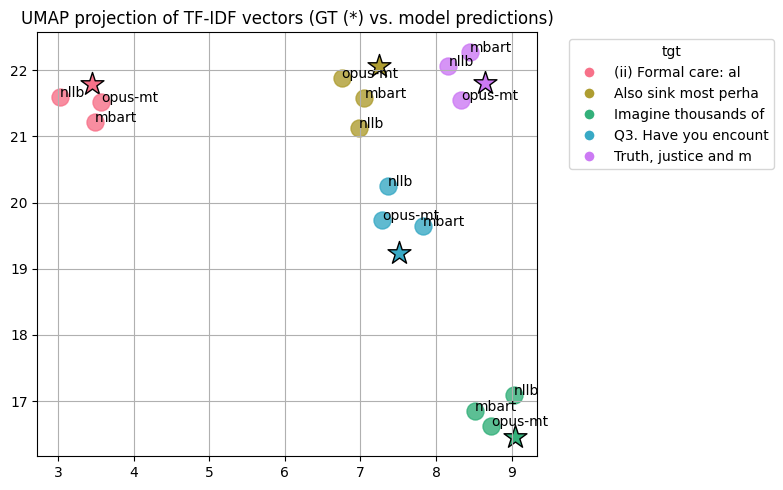

In [32]:
# 2. TF-IDF
vectorizer = TfidfVectorizer(lowercase=True, stop_words=None, max_features=20_000)
X = vectorizer.fit_transform(sentences)   # shape: (n_sent, n_features)
fontsize = 10
S = 150

# 3. UMAP
reducer = umap.UMAP(n_neighbors=5, min_dist=0.1, metric="cosine", random_state=42)
XY = reducer.fit_transform(X)             # shape: (n_sent, 2)

# 4. Plot
plt.figure(figsize=(8, 5))
unique_samples = sorted(set(labels))
palette = sns.color_palette("husl", n_colors=len(unique_samples))
color_map = {sam: palette[i] for i, sam in enumerate(unique_samples)}

for i, (x, y) in enumerate(XY):
    color = color_map[labels[i]]
    if markers[i] == "gt":      
        plt.scatter(x, y, marker="*", s=S*2, c=[color], edgecolor="black")
    else:                       
        plt.scatter(x, y, c=[color], s=S, alpha=0.8)
        plt.text(x, y, markers[i], fontsize=fontsize, ha="left")

legend_elements = [plt.Line2D([0], [0], marker="o", color="w",
                              markerfacecolor=color_map[sam], markersize=8, label=sam)
                   for sam in unique_samples]
plt.legend(handles=legend_elements, title="tgt", bbox_to_anchor=(1.05, 1), fontsize=fontsize, loc='best')
plt.title("UMAP projection of TF-IDF vectors (GT (*) vs. model predictions)")
plt.tight_layout()
plt.grid(True)
plt.savefig('./cluster.jpg')

For each source sentences, we run all three models with finetuning to generate a prediction.

The predictions of all models and the ground truth target sentence are first vectorized using TF-IDF and then reduced to two dimension with UMAP.

The two-dimensional space thereby is referred to the semantic space.

Finally, the points which correspond to the same source sentences are in the same color.

We can observe that the predictions of the same source sentences form clusters in the semantic space.

The predictions of opus-mt are also closer to the ground truth in more cases, followed by mbart, which coincidents with the models' performances.